In [16]:
import pandas as pd
import numpy as np

df_vendas = pd.read_csv('vendas_tech.csv', low_memory=False)
df_gerentes = pd.read_excel('gerentes_lojas.xlsx')

In [17]:
# Inspeção
#display(df_vendas)
#display(df_vendas.head(15)) - 15 primeiras linhas
#display(df_vendas.tail(15)) - 15 últimas linhas
#display(df_vendas.sample(15)) - Puxa 15 linhas aleatórias, sample = amostra
#display(df_vendas.shape) - Retorna quantas linhas e quantas colunas tem 
#display(df_vendas.columns) - retorna uma lista com todas as colunas do dataframe
#display(list(df_vendas.columns)) - transformar em uma lista python normal
#display(df_vendas.info()) #- Pegar as informações da base de dados
#display(df_vendas.describe())


In [18]:
#Tratamento de dados

#Colunas
df_analise = df_vendas.drop(columns=['Data_Base'])

#Nulos
#df_analise = df_analise.dropna() - Exclui todas as linhas que tem 1 valor nulo
df_analise['Loja'] = df_analise['Loja'].fillna('Online')

#Tipos de dados
df_analise['Data'] = pd.to_datetime(df_analise['Data'], format="%Y-%m-%d")

#Padronização
df_analise['Loja'] = df_analise['Loja'].str.strip()
df_analise['Loja'] = df_analise['Loja'].str.title()

df_gerentes['Loja'] = df_gerentes['Loja'].str.strip()
df_gerentes['Loja'] = df_gerentes['Loja'].str.title()

#Encadeamento
#df_analise['Loja'] = df_analise['Loja'].fillna('Online').str.strip().str.title()

#Duplicatas
df_analise = df_analise.drop_duplicates(subset=['ID_Pedido']) # Tem um parametro keep= que vem com 'first' como defalt e pode colocar 'last', significa manter, vai excluir as duplicatas, então vai manter o primeiro ou o último

display(df_analise)
display(df_analise.info())

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


None

In [19]:
# Criar nova colunas

# Faturamento
df_analise['Faturamento'] = df_analise['Preco_Unitario'] * df_analise['Qtd']

# Forma de venda
df_analise['Forma_de_Venda'] = np.where(df_analise['Loja']=='Online', 'Online', 'Presencial')

# Região
display(df_analise['Loja'].unique())

dic_regiao = {
    'São Paulo': 'Sudeste',
    'Belo Horizonte': 'Sudeste',
    'Online': 'Online',
    'Rio De Janeiro': 'Sudeste',
    'Salvador': 'Nordeste',
    'Recife': 'Nordeste',
    'Curitiba': 'Sul',
    'Porto Alegre': 'Sul'
}

df_analise['Regiao'] = df_analise['Loja'].map(dic_regiao)

display(df_analise)
display(df_analise.isna().sum())

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Regiao
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_de_Venda    0
Regiao            0
dtype: int64

In [20]:
# analisar -> filtrar

df_analise = df_analise.sort_values(by=['Data', 'Faturamento'], ascending=False)
df_analise = df_analise.reset_index(drop=True)

#.loc: id do pedido -> por nome da coluna e nome da linha
id_pedido = 4

loja = df_analise.loc[df_analise['ID_Pedido']==4, 'Loja'].values[0]
produto = df_analise.loc[df_analise['ID_Pedido']==4, 'Produto'].values[0]
cliente = df_analise.loc[df_analise['ID_Pedido']==4, 'Cliente'].values[0]

print(loja)
print(produto)
print(cliente)

#.iloc -> por posição
id_pedido = 4
loja = df_analise.iloc[3, 2]
produto = df_analise.iloc[3, 3]
cliente = df_analise.iloc[3, 6]

print(loja, produto, cliente)

# condicional
#df_id_pedido_4 = df_analise[df_analise['ID_Pedido']==4]
#display(df_id_pedido_4)

# exportar pedaços da base
df_vendas_sao_paulo = df_analise[df_analise['Loja']=='São Paulo']
df_vendas_sao_paulo.to_csv('Vendas_SP.csv', index=False)

# Exportar as vendas de 2024
df_vendas_2024 = df_analise[df_analise['Data'].dt.year==2024] # Ou df_analise['Data']>='2024-01-01

# duplas condições
condicao = df_analise['Produto']=='Cabo HDMI'
condicao2 = df_analise['Regiao']=='Sul'
df_vendas_HDMI_Sul = df_analise[condicao & condicao2]
display(df_vendas_HDMI_Sul)

Rio De Janeiro
Mouse Gamer
Cliente_17343
Recife Notebook Dell Cliente_11509


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Regiao
117,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Presencial,Sul
118,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Presencial,Sul
119,64473,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_11598,80.0,Presencial,Sul
125,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Presencial,Sul
126,78584,2024-12-30,Curitiba,Cabo HDMI,40.0,1,Cliente_21307,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99987,35599,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_18680,40.0,Presencial,Sul
99988,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Presencial,Sul
99989,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Presencial,Sul
99994,70138,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_9348,40.0,Presencial,Sul


In [21]:
# Analise por agrupamento
#display(df_analise)

# Ranking de faturamento por loja
analise_loja = df_analise[['Loja', 'Faturamento']].groupby('Loja').sum()
analise_loja = analise_loja.sort_values(by='Faturamento', ascending=False)
analise_loja = analise_loja.reset_index()
analise_loja['Faturamento'] = analise_loja['Faturamento'].map('R$ {:,.2f}'.format)

#Ranking de produtos que mais venderam no online
df_vendas_online = df_analise[df_analise['Loja']=='Online']
analise_loja_online = df_vendas_online[['Produto', 'Qtd', 'Faturamento']].groupby('Produto').sum()
produtos_mais_vendidos_online = analise_loja_online.sort_values(by='Qtd', ascending=False)
produtos_mais_faturados_online = analise_loja_online.sort_values(by='Faturamento', ascending=False)
produtos_mais_vendidos_online['Faturamento'] = produtos_mais_vendidos_online['Faturamento'].map('R$ {:,.2f}'.format)
produtos_mais_faturados_online['Faturamento'] = produtos_mais_faturados_online['Faturamento'].map('R$ {:,.2f}'.format)
produtos_mais_faturados_online = produtos_mais_faturados_online.rename(columns={'Qtd': 'Quantidade'})
produtos_mais_vendidos_online = produtos_mais_vendidos_online.rename(columns={'Qtd': 'Quantidade'})
print('Ranking de Produtos mais vendidos')
display(produtos_mais_vendidos_online)
print('Ranking de Produtos mais faturados')
display(produtos_mais_faturados_online)


Ranking de Produtos mais vendidos


,Quantidade,Faturamento
Produto,,
Notebook HP,442,"R$ 1,414,400.00"
Cabo HDMI,403,"R$ 16,120.00"
iPhone 14,390,"R$ 2,145,000.00"
Mouse Gamer,379,"R$ 45,480.00"
Notebook Dell,369,"R$ 1,291,500.00"
Teclado Mecânico,343,"R$ 85,750.00"
"Monitor 27""",332,"R$ 398,400.00"
Smartphone Samsung,311,"R$ 684,200.00"


Ranking de Produtos mais faturados


,Quantidade,Faturamento
Produto,,
iPhone 14,390,"R$ 2,145,000.00"
Notebook HP,442,"R$ 1,414,400.00"
Notebook Dell,369,"R$ 1,291,500.00"
Smartphone Samsung,311,"R$ 684,200.00"
"Monitor 27""",332,"R$ 398,400.00"
Teclado Mecânico,343,"R$ 85,750.00"
Mouse Gamer,379,"R$ 45,480.00"
Cabo HDMI,403,"R$ 16,120.00"


In [22]:
# analise de ranking por loja e por produto
# quais produtos venderam mais em cada loja
analise_produtos_em_lojas = df_analise[['Loja', 'Produto', 'Qtd']].groupby(['Loja', 'Produto']).sum()
analise_lojas_em_produtos = df_analise[['Loja', 'Produto', 'Qtd']].groupby(['Produto', 'Loja']).sum()
# pd.set_option('display.display.max_rows', None) - para mostrar todas as linhas do dataframe, sem isso ele mostra só as primeiras e as últimas
# Para fazer isso só para um dataframe específico, sem alterar a configuração global do pandas, podemos usar o with pd.option_context, que é um gerenciador de contexto que permite definir opções temporárias para o pandas. Dentro do bloco with, as opções definidas serão aplicadas apenas ao código dentro desse bloco, e após sair do bloco, as opções voltarão ao estado anterior.
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print('Analise Produtos em Lojas')
    display(analise_produtos_em_lojas)
    print('Analise Lojas em Produtos')
    display(analise_lojas_em_produtos)

Analise Produtos em Lojas


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
               Smartphone Samsung  2597
               Teclado Mecânico    2609
               iPhone 14           2478
Curitiba       Cabo HDMI           2698
               Monitor 27"         2626
               Mouse Gamer         2600
               Notebook Dell       2517
               Notebook HP         2529
               Smartphone Samsung  2444
               Teclado Mecânico    2742
               iPhone 14           2652
Online         Cabo HDMI            403
               Monitor 27"          332
               Mouse Gamer          379
               Notebook Dell        369
               Notebook HP          442
               Smartphone Samsung   311
               Teclado Mecânico     343
               iPhone 14            390
Porto Alegre   Cabo HDMI           2571
               Monitor 27"         2655
               Mouse Gamer         2611
               Notebook Dell       2770
               Notebook HP         2511
               Smartphone Samsung  2603
               Teclado Mecânico    2598
               iPhone 14           2540
Recife         Cabo HDMI           2534
               Monitor 27"         2647
               Mouse Gamer         2639
               Notebook Dell       2566
               Notebook HP         2651
               Smartphone Samsung  2660
               Teclado Mecânico    2775
               iPhone 14           2652
Rio De Janeiro Cabo HDMI           2747
               Monitor 27"         2798
               Mouse Gamer         2652
               Notebook Dell       2534
               Notebook HP         2614
               Smartphone Samsung  2626
               Teclado Mecânico    2548
               iPhone 14           2702
Salvador       Cabo HDMI           2566
               Monitor 27"         2545
               Mouse Gamer         2711
               Notebook Dell       2512
               Notebook HP         2785
               Smartphone Samsung  2627
               Teclado Mecânico    2579
               iPhone 14           2671
São Paulo      Cabo HDMI           2649
               Monitor 27"         2796
               Mouse Gamer         2714
               Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

Analise Lojas em Produtos


Qtd
Produto            Loja                
Cabo HDMI          Belo Horizonte  2636
                   Curitiba        2698
                   Online           403
                   Porto Alegre    2571
                   Recife          2534
                   Rio De Janeiro  2747
                   Salvador        2566
                   São Paulo       2649
Monitor 27"        Belo Horizonte  2625
                   Curitiba        2626
                   Online           332
                   Porto Alegre    2655
                   Recife          2647
                   Rio De Janeiro  2798
                   Salvador        2545
                   São Paulo       2796
Mouse Gamer        Belo Horizonte  2465
                   Curitiba        2600
                   Online           379
                   Porto Alegre    2611
                   Recife          2639
                   Rio De Janeiro  2652
                   Salvador        2711
                   São Paulo       2714
Notebook Dell      Belo Horizonte  2654
                   Curitiba        2517
                   Online           369
                   Porto Alegre    2770
                   Recife          2566
                   Rio De Janeiro  2534
                   Salvador        2512
                   São Paulo       2535
Notebook HP        Belo Horizonte  2775
                   Curitiba        2529
                   Online           442
                   Porto Alegre    2511
                   Recife          2651
                   Rio De Janeiro  2614
                   Salvador        2785
                   São Paulo       2592
Smartphone Samsung Belo Horizonte  2597
                   Curitiba        2444
                   Online           311
                   Porto Alegre    2603
                   Recife          2660
                   Rio De Janeiro  2626
                   Salvador        2627
                   São Paulo       2476
Teclado Mecânico   Belo Horizonte  2609
                   Curitiba        2742
                   Online           343
                   Porto Alegre    2598
                   Recife          2775
                   Rio De Janeiro  2548
                   Salvador        2579
                   São Paulo       2589
iPhone 14          Belo Horizonte  2478
                   Curitiba        2652
                   Online           390
                   Porto Alegre    2540
                   Recife          2652
                   Rio De Janeiro  2702
                   Salvador        2671
                   São Paulo       2735

In [24]:
# quais gerentes bateram as metas
df_meta = df_analise[(df_analise['Data'].dt.year==2023) & (df_analise['Data'].dt.month==1)]

df_meta = df_meta[['Loja', 'Faturamento']].groupby('Loja', as_index=False).sum()

df_meta = df_meta.merge(df_gerentes, on='Loja', how='left')

df_meta['Bateu_Meta'] = np.where(df_meta['Faturamento'] >= df_meta['Meta_Mensal'], 'Sim', 'Não')
display(df_meta)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu_Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


,Faturamento
Ano-Mes,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


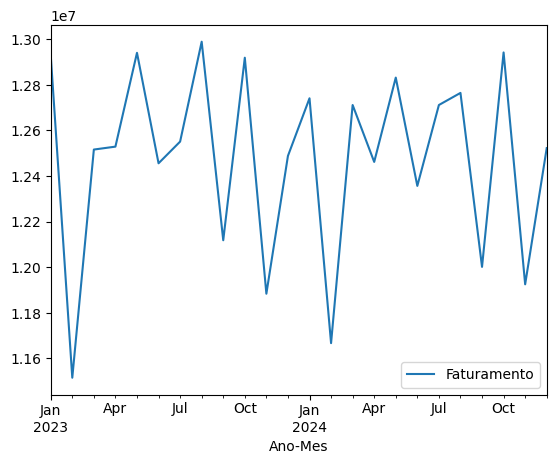

In [26]:
df_analise['Ano-Mes'] = df_analise['Data'].dt.to_period('M')
df_vendas_mes = df_analise[['Ano-Mes', 'Faturamento']].groupby('Ano-Mes').sum()
df_vendas_mes.plot()
display(df_vendas_mes)